# 第16课 · 这个变换能撤销吗？——行列式（determinant）判生死，逆矩阵（inverse matrix）来还原

> **读法**：主路径先把 **2×2** 的 det / 逆公式钉死；后半 3×3 与补充例题是加练，2×2 不稳时先别往下冲。

**学习目标**
1. 理解行列式的几何含义：`det(A)` 等于矩阵列向量张成的平行四边形有向面积，`det=0` 表示空间被压扁
2. 用公式 `ad − bc` 实现 `det_2x2(M)` 和 `inv_2x2(M)`，当 `det=0` 时返回 `None`
3. 用余子式展开计算 3×3 行列式，对照补充例题验证 `|A| = 2`
4. 用伴随矩阵公式 `A⁻¹ = adj(A)/|A|` 求 3×3 逆矩阵，验证 `A @ A⁻¹ = I`
5. 理解 `det = 0` 对 Aurora 协方差白化步骤的影响（奇异矩阵无法白化，需加正则项 `ε·I`）

**为什么对 Aurora 重要**：在 Aurora 特征提取中，`det(M) = 0` 意味着协方差矩阵（covariance matrix）奇异、白化（whitening）步骤无法进行；`A⁻¹` 直接出现在 Mahalanobis 距离计算和最小二乘求解里。

← **上一课**　[L15 · 高斯消元](L15_linear_systems.ipynb)

> 上节课学习了 **高斯消元**：方程组 Ax=b 的消元过程，行阶梯形与解的存在性分类。  
> 本课将探讨 **行列式与逆矩阵**。

## 本课剧情：矩阵在"消灭"信息吗？

想象一台照相机。它把三维空间压缩成二维照片——深度信息消失了。这个变换**不可逆**：无法从照片还原三维场景。

数学上，这对应 `det(A) = 0`：行列式为零 → 矩阵把空间"压扁"了一个维度 → 信息丢失 → 不可逆。

反过来，`det(A) ≠ 0` → 变换保留了所有维度 → 存在逆变换 `A⁻¹`。

行列式（determinant）的几何含义：
- **2D**：单位正方形经 A 变换后的**有向面积**（可以为负，表示翻转）
- **3D**：单位立方体经 A 变换后的**有向体积**
- **|det| = 2**：面积翻倍；**det = 0**：压扁成线（不可逆）；**det < 0**：翻转

本课你将实现 `det_2x2(M)` 和 `inv_2x2(M)`——2×2 情形有闭式公式，手算可验证。

## 1. 2×2 行列式：`det = ad − bc`

$$A=\begin{pmatrix}a&b\\c&d\end{pmatrix},\quad \det(A)=ad-bc$$

**几何直觉**：想象把 [1,0] 变成 [a,c]，把 [0,1] 变成 [b,d]。这两个向量张成的平行四边形面积就是 |det(A)|。

**手算例子**：A = [[3, 1], [2, 4]]  
`det = 3×4 − 1×2 = 12 − 2 = 10`（面积扩大 10 倍）

**逆矩阵**（det ≠ 0 时才存在）：
$$A^{-1} = \frac{1}{ad-bc}\begin{pmatrix}d&-b\\-c&a\end{pmatrix}$$

注意规律：主对角线互换，副对角线变号，整体除以 det。

**奇异矩阵**（det = 0）：A = [[1, 2], [2, 4]]，det = 1×4 − 2×2 = 0。  
两行成比例 → 空间被压成一条线 → 逆矩阵不存在。

## 1.5 停一下：`det=ad-bc` 里的每个符号到底对应图上的什么？

**同学提问回顾**：琳达和小雨都问到——"张成"是什么意思？为什么一个平行四边形的面积公式长成 `ad-bc` 这个样子？

先讲个生活化的类比。想象你在墙上钉了两根橡皮筋的一端，钉在同一个点上（原点）。第一根橡皮筋你拉到点 `(a, c)`，第二根拉到点 `(b, d)`。这两根橡皮筋"张开"出来的那个平行四边形（一个"歪的矩形"），它的面积就是行列式在算的东西。

矩阵 `A = [[a, b], [c, d]]` 的两个**列向量**（不是行向量！）恰好就是 `(a, c)` 和 `(b, d)`——因为按 NumPy/线性代数的习惯，矩阵的第一列是 `[a, c]`，第二列是 `[b, d]`。这两个向量"张成"（span）的平行四边形，面积就是 `|ad-bc|`。

**举两个具体例子，先建立画面感**：
- `A = [[2, 0], [0, 2]]`：两个列向量是 `(2, 0)` 和 `(0, 2)`，也就是 x 轴和 y 轴上各拉长到 2 的两条边——这就是一个边长为 2 的正方形，面积 = 4。用公式验证：`ad-bc = 2×2 - 0×0 = 4`，对上了。
- `A = [[1, 1], [0, 1]]`：列向量是 `(1, 0)` 和 `(1, 1)`。第一条边沿 x 轴长度 1，第二条边斜着指向 `(1,1)`。这是一个被"推歪"的平行四边形（剪切变换），但底边长 1、高还是 1（斜边只在 x 方向偏移，y 方向没变），面积仍然是 1×1=1。公式验证：`ad-bc = 1×1 - 1×0 = 1`。

**这就是 `ad-bc` 公式的来源——它不是凭空规定的，而是"底 × 高"公式在坐标系里的展开**：把 `(a,c)` 当底边，这个平行四边形的高，就是 `(b,d)` 在垂直于 `(a,c)` 方向上的投影长度。把这个几何计算展开、化简到最后，就得到 `ad-bc`——所以这个公式本质上仍然是"底乘高"，只是换了一种代数写法而已。

下面用代码把这两个例子画出来，你可以直接看到"张成的平行四边形"长什么样。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


红色箭头=第一列 (a,c)，绿色箭头=第二列 (b,d)；它们围出的平行四边形面积就是 |det|。


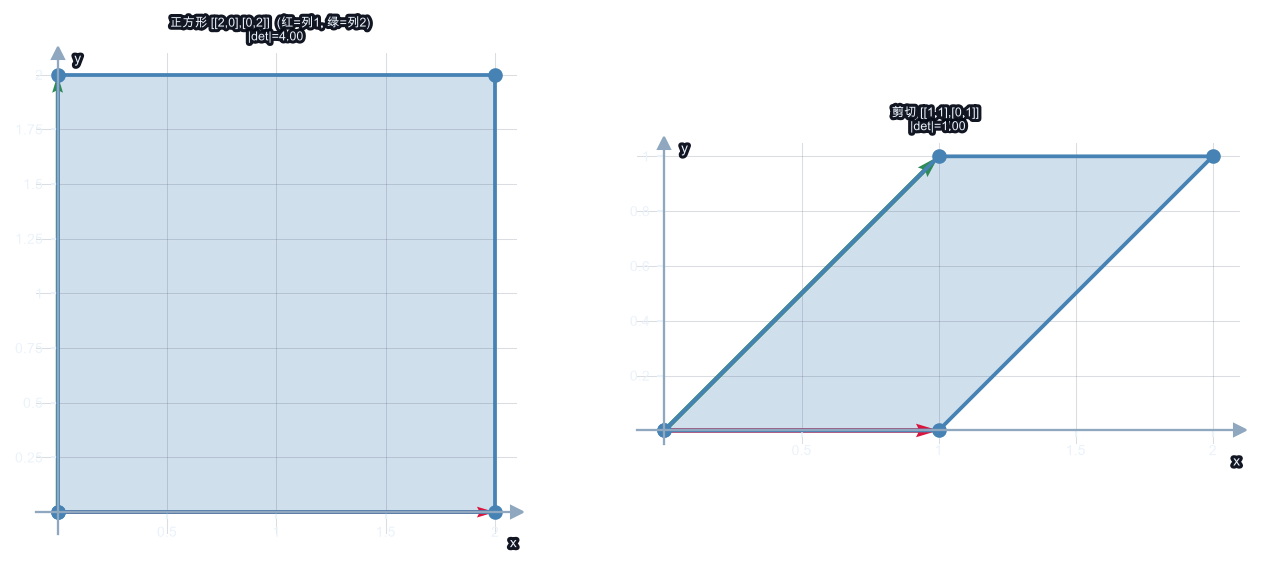

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def plot_span(A, title):
    A = np.array(A, dtype=float)
    col1, col2 = A[:, 0], A[:, 1]
    origin = np.array([0, 0])
    # 平行四边形的四个顶点：原点 -> 列1 -> 列1+列2 -> 列2 -> 回到原点
    pts = np.array([origin, col1, col1 + col2, col2, origin])
    plt.plot(pts[:, 0], pts[:, 1], 'o-', color='steelblue')
    plt.fill(pts[:-1, 0], pts[:-1, 1], alpha=0.25, color='steelblue')
    plt.quiver(0, 0, col1[0], col1[1], angles='xy', scale_units='xy', scale=1, color='crimson')
    plt.quiver(0, 0, col2[0], col2[1], angles='xy', scale_units='xy', scale=1, color='seagreen')
    plt.title(f'{title}\n|det|={abs(np.linalg.det(A)):.2f}', fontsize=10)
    plt.axhline(0, color='gray', lw=0.5); plt.axvline(0, color='gray', lw=0.5)
    plt.gca().set_aspect('equal')

plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
plot_span([[2, 0], [0, 2]], '正方形 [[2,0],[0,2]]  (红=列1, 绿=列2)')
plt.subplot(1, 2, 2)
plot_span([[1, 1], [0, 1]], '剪切 [[1,1],[0,1]]')
plt.tight_layout()
plt.show()
print('红色箭头=第一列 (a,c)，绿色箭头=第二列 (b,d)；它们围出的平行四边形面积就是 |det|。')


## 1.6 逆矩阵公式 `[[d,-b],[-c,a]]/det` 是怎么"解"出来的？

老陈、琳达、小雨都问了同一个问题：这个"主对角线互换、副对角线变号"的公式，到底是拍脑袋规定的，还是能推出来的？

答案是：能推出来，而且推导过程只用到你已经会的东西——**解方程组**。

**先想清楚"逆矩阵"到底要满足什么条件**。`A⁻¹` 的定义就是：`A` 乘上它，要变回单位矩阵 `I=[[1,0],[0,1]]`。设 `A⁻¹` 里的四个未知数是 `x, y, z, w`：

$$A \cdot A^{-1} = \begin{pmatrix}a&b\\c&d\end{pmatrix}\begin{pmatrix}x&y\\z&w\end{pmatrix} = \begin{pmatrix}1&0\\0&1\end{pmatrix}$$

**把左边的矩阵乘法按定义展开**（每个位置 = 对应行乘对应列，逐项相加）：

$$\begin{pmatrix}ax+bz & ay+bw\\cx+dz & cy+dw\end{pmatrix} = \begin{pmatrix}1&0\\0&1\end{pmatrix}$$

这给了我们 4 个方程，正好可以解出 4 个未知数：
- 第一列（对应等式右边的第一列 `[1,0]`）：`ax+bz=1`，`cx+dz=0`
- 第二列（对应等式右边的第二列 `[0,1]`）：`ay+bw=0`，`cy+dw=1`

**解第一列**（`x, z`）：从 `cx+dz=0` 得 `z = -cx/d`（假设 d≠0），代回第一个方程消掉 `z`，整理后解出：
$$x=\frac{d}{ad-bc}, \qquad z=\frac{-c}{ad-bc}$$

**解第二列**（`y, w`）用同样的消元方法，解出：
$$y=\frac{-b}{ad-bc}, \qquad w=\frac{a}{ad-bc}$$

**把这四个解拼回矩阵**：
$$A^{-1}=\begin{pmatrix}x&y\\z&w\end{pmatrix}=\frac{1}{ad-bc}\begin{pmatrix}d&-b\\-c&a\end{pmatrix}$$

对上了！这正是课程给出的闭式公式——它不是规定，而是"解 4 元一次方程组"的结果。`d` 和 `a` 换了位置（主对角线互换），`b` 和 `c` 前面多了负号（副对角线变号），都是解方程时自然消元出来的，不是需要死记硬背的口诀。

下面用代码替你把这两组方程都解一遍（代入具体数值），你可以看到解出来的 `x,y,z,w` 恰好就是公式给出的值。

In [3]:
import numpy as np

# 用具体数值验证上面的推导：A=[[3,1],[2,4]]
a, b, c, d = 3., 1., 2., 4.
det = a*d - b*c

# 解第一列方程组: a*x+b*z=1, c*x+d*z=0
coef = np.array([[a, b], [c, d]])
x, z = np.linalg.solve(coef, [1, 0])

# 解第二列方程组: a*y+b*w=0, c*y+d*w=1
y, w = np.linalg.solve(coef, [0, 1])

A_inv_solved = np.array([[x, y], [z, w]])
A_inv_formula = (1/det) * np.array([[d, -b], [-c, a]])

print('解方程组得到:\n', np.round(A_inv_solved, 6))
print('闭式公式给出:\n', np.round(A_inv_formula, 6))
print('两者一致:', np.allclose(A_inv_solved, A_inv_formula))


解方程组得到:
 [[ 0.4 -0.1]
 [-0.2  0.3]]
闭式公式给出:
 [[ 0.4 -0.1]
 [-0.2  0.3]]
两者一致: True


## 符号入口：先看形状，再看运算

本节对象是方阵 `M`（shape `(n, n)`）。2×2 的行列式是 `ad−bc`，可以直接计算；3×3 的行列式通过余子式展开，把问题拆成三个 2×2 子式来处理。

## 2. ✏️ 实现 `det_2x2(M)` 与 `inv_2x2(M)`

**推理路线**：
1. 解包矩阵：`a, b = M[0]`，`c, d = M[1]`，得到四个标量
2. 计算行列式：`det = a*d - b*c`；这是两列向量（vector） `[a,c]` 和 `[b,d]` 张成平行四边形的有向面积
3. 判断可逆性：`det == 0` 时矩阵把平面压成直线，无法求逆，应返回 `None` 而非除以零
4. 构造逆矩阵：对角元素互换（`d` 移到左上角，`a` 移到右下角），副对角元素取反，整体乘以 `1/det`

**参考输入输出**：`M=[[1,0],[0,2]]` → `det=2`，`inv=[[1,0],[0,0.5]]`；`M=[[1,2],[2,4]]` → `det=0`，不可逆

> 💡 需要提示？完成练习后可参考 `solutions/` 目录中的参考实现。


### 写代码前，先把变量表补完整

写 `det_2x2` 前明确三件事：
- 输入：`M`，shape `(2, 2)`，元素解包为 `a, b, c, d`
- 关键步骤：`det = a*d - b*c`；det 为 0 时无法求逆
- 返回：`det_2x2` 返回标量；`inv_2x2` 返回 shape `(2, 2)` 的矩阵

In [4]:
import numpy as np
def det_2x2(M):
    raise NotImplementedError("请实现：解包 a,b,c,d 后返回 a*d - b*c")

def inv_2x2(M):
    raise NotImplementedError("请实现：det=0 时返回 None，否则返回 2×2 逆矩阵")


## 动手观察：det 值与可逆性

运行下面这格，观察 `det` 随矩阵系数的变化：当两行成比例时 det 变为 0，`inv_2x2` 应当拒绝求逆。

In [5]:
import numpy as np

# 行列式 = 单位正方形变换后的面积缩放因子
mats = {
    '缩放 2x':    np.array([[2.,0.],[0.,2.]]),
    '旋转 45°':  np.array([[np.cos(np.pi/4), -np.sin(np.pi/4)],
                           [np.sin(np.pi/4),  np.cos(np.pi/4)]]),
    '剪切':       np.array([[1.,2.],[0.,1.]]),
    '秩不满':     np.array([[1.,2.],[2.,4.]]),
}
for name, A in mats.items():
    d = np.linalg.det(A)
    print(f'{name:10s}  det={d:+.4f}')
print('旋转：|det|=1（不改变面积）；秩不满：det=0（压缩至低维）')


缩放 2x       det=+4.0000
旋转 45°      det=+1.0000
剪切          det=+1.0000
秩不满         det=+0.0000
旋转：|det|=1（不改变面积）；秩不满：det=0（压缩至低维）


### 翻转到底是什么？—— 镜子 vs. 转盘

老陈和小雨都卡在同一个词上：课程说"det<0 表示翻转（左手变右手）"，但上面的旋转矩阵明明也把向量转到了别的方向，为什么它的 det 却是正的（`|det|=1`）？

先用一个类比说清楚"翻转"和"旋转"的区别：想象你面前一枚硬币。**旋转**是让硬币在桌面上打转——正面一直朝上，只是转了个方向。**翻转**是把硬币"翻个面"——正面变成反面，像照镜子一样左右（或上下）互换。放到二维平面里，"翻转"对应的是**镜像对称**：把整个平面沿着某条线折过去。

具体看一个例子：矩阵 `F = [[1, 0], [0, -1]]` 是关于 x 轴的镜像（reflection）。它把点 `(x, y)` 变成 `(x, -y)`——y 坐标变号，就像照镜子一样上下翻了过来。算它的行列式：`det(F) = 1×(-1) - 0×0 = -1`，正是负的。

再对比旋转矩阵（比如上面的"旋转45°"）：它的 det 恒等于 1（不管转多少度），因为旋转只改变方向，不改变面积，也不需要把图形"掀起来翻个面"。

下面画图对比：同一个不对称的"L"形状，分别经过旋转和镜像变换后会变成什么样（用对称图形看不出翻转和旋转的区别，所以特意选了不对称的形状）。你会看到旋转后的"L"仍然是"正常"的 L（只是转了个方向，能靠纯转动转回去）；镜像后的"L"变成了它的镜子像（无法只靠转动转回去），这就是"翻转"。

旋转后的L仍然是"正常"的L（能通过纯转动回到原图）；镜像后的L变成了它的镜子像，无法只靠转动转回去——这就是det<0的"翻转"。


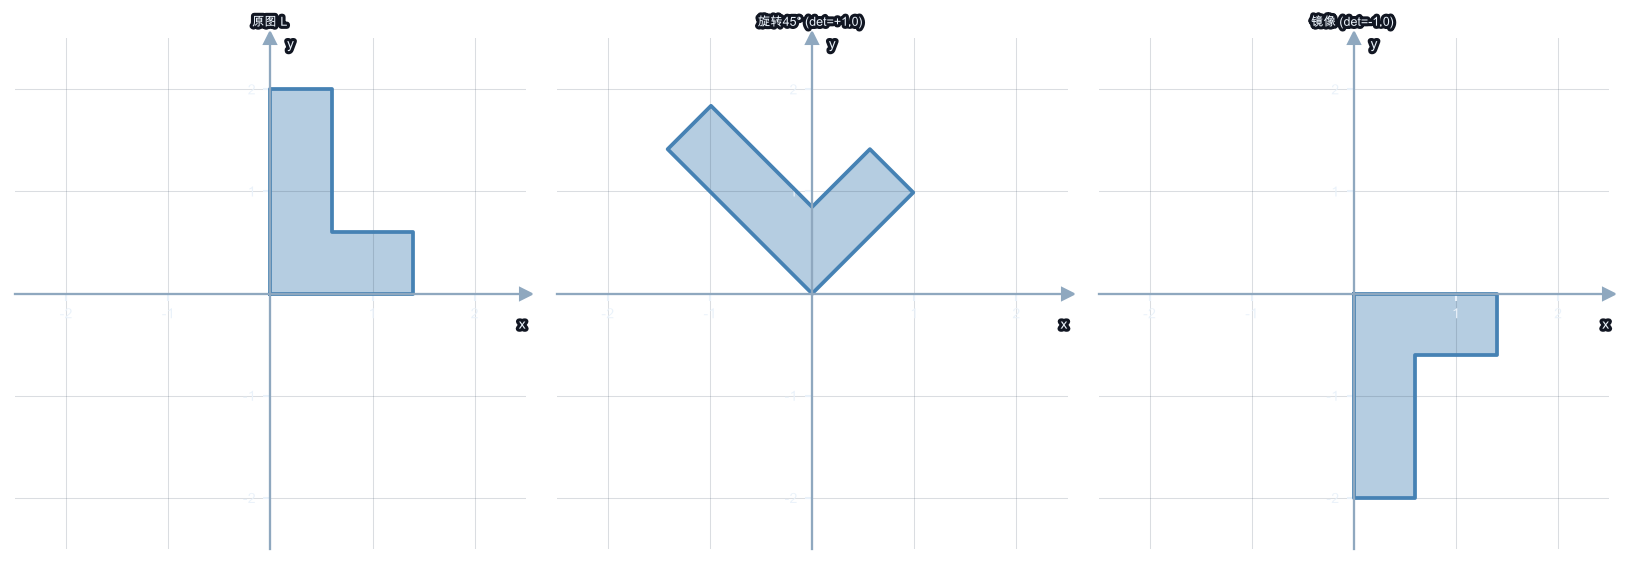

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 用一个不对称的"L"形状，才能看出翻转和旋转的区别（对称图形转/翻看起来一样）
L_shape = np.array([[0,0],[0,2],[0.6,2],[0.6,0.6],[1.4,0.6],[1.4,0],[0,0]]).T  # shape (2, N)

theta = np.pi/4
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])  # 旋转45°，det=+1
F = np.array([[1., 0.], [0., -1.]])  # 关于x轴镜像，det=-1

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, M, title in zip(
    axes,
    [np.eye(2), R, F],
    ['原图 L', f'旋转45° (det={np.linalg.det(R):+.1f})', f'镜像 (det={np.linalg.det(F):+.1f})']
):
    pts = M @ L_shape
    ax.fill(pts[0], pts[1], alpha=0.4, color='steelblue')
    ax.plot(pts[0], pts[1], color='steelblue')
    ax.set_title(title, fontsize=10)
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.set_aspect('equal'); ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
plt.tight_layout()
plt.show()
print('旋转后的L仍然是"正常"的L（能通过纯转动回到原图）；镜像后的L变成了它的镜子像，无法只靠转动转回去——这就是det<0的"翻转"。')


## 代码实验：不同矩阵的 det 和逆

下面遍历几组矩阵，对比 det 值与逆矩阵是否存在。

In [7]:
import numpy as np

# 3x3 行列式手算 vs NumPy
A = np.array([[1.,2.,3.],[4.,5.,6.],[7.,8.,10.]])
det_np = np.linalg.det(A)
# 按第一行展开 (cofactor expansion)
d0 = A[0,0]*(A[1,1]*A[2,2]-A[1,2]*A[2,1])
d1 =-A[0,1]*(A[1,0]*A[2,2]-A[1,2]*A[2,0])
d2 = A[0,2]*(A[1,0]*A[2,1]-A[1,1]*A[2,0])
det_manual = d0+d1+d2
print(f'NumPy det   = {det_np:.6f}')
print(f'手算展开 det = {det_manual:.6f}')
print(f'误差 = {abs(det_np-det_manual):.2e}')
print(f'可逆？ {"是" if abs(det_np)>1e-10 else "否，奇异矩阵"}')


NumPy det   = -3.000000
手算展开 det = -3.000000
误差 = 8.88e-16
可逆？ 是


In [8]:
M = np.array([[4.,3.],[6.,3.]])
try:
    got_det = det_2x2(M)
    ref_det = np.linalg.det(M)
    print(f"det_2x2 = {got_det:.6f}  numpy = {ref_det:.6f}")
    assert abs(got_det - ref_det) < 1e-9, f"det_2x2 误差 {abs(got_det - ref_det):.2e}"
    print("✅ 行列式 通过")
except (NotImplementedError, TypeError) as e:
    print(f"⏭️ det_2x2 尚未实现：{e}")


⏭️ det_2x2 尚未实现：请实现：解包 a,b,c,d 后返回 a*d - b*c


In [9]:
try:
    got_inv = inv_2x2(M)
    ref_inv = np.linalg.inv(M)
    print("inv_2x2:\n", np.round(got_inv, 6))
    print("numpy:\n", np.round(ref_inv, 6))
    assert np.allclose(got_inv, ref_inv), "逆矩阵误差超限"
    print("✅ 逆矩阵 通过")
except (NotImplementedError, TypeError) as e:
    print(f"⏭️ inv_2x2 尚未实现：{e}")


⏭️ inv_2x2 尚未实现：请实现：det=0 时返回 None，否则返回 2×2 逆矩阵


### 怎么知道该造一个什么样的"奇异矩阵"来测试？

老陈问了一个很实际的问题：下面的测试用例给了 `singular = [[1,2],[2,4]]`，但如果换成别的题目，要怎么才能想到构造这样一个 det=0 的例子？有没有什么"配方"？

有一个简单可靠的配方：**只要让矩阵的某一行是另一行的倍数**，这个矩阵的 det 必然是 0。

为什么？回到"张成的平行四边形"这个画面（1.5 节）：如果第二个向量 `(b,d)` 就是第一个向量 `(a,c)` 乘上某个倍数 `k`（也就是 `b=ka, d=kc`），那么这两个向量方向完全相同（或相反），它们"张成"不出一个有面积的平行四边形——只能落在同一条直线上，面积自然是 0。代入公式验证：`det = a(kc) - (ka)c = kac - kac = 0`，恒成立。

**配方**：任取一个向量 `v = (p, q)`，构造 `A = [[p, q], [k*p, k*q]]`（第二行是第一行的 k 倍），这个矩阵一定奇异。比如 `v=(1,2)`, `k=2` 就得到下面测试用的例子 `[[1,2],[2,4]]`。

下面代码随便生成几个"比例矩阵"，验证它们的 det 确实都是 0：

In [10]:
import numpy as np

for p, q, k in [(1, 2, 2), (3, -1, 4), (0.5, 5, -2)]:
    A_sing = np.array([[p, q], [k*p, k*q]])
    print(f'v=({p},{q}), k={k}  ->  A={A_sing.tolist()}  det={np.linalg.det(A_sing):.6f}')
print('无论 v 和 k 怎么选，只要第二行是第一行的倍数，det 恒为 0。')


v=(1,2), k=2  ->  A=[[1, 2], [2, 4]]  det=0.000000
v=(3,-1), k=4  ->  A=[[3, -1], [12, -4]]  det=0.000000
v=(0.5,5), k=-2  ->  A=[[0.5, 5.0], [-1.0, -10.0]]  det=0.000000
无论 v 和 k 怎么选，只要第二行是第一行的倍数，det 恒为 0。


In [11]:
# 奇异矩阵断言 — 验证规格文档承诺的核心分支
# singular = [[1,2],[2,4]]，det = 1*4-2*2 = 0
try:
    singular = np.array([[1., 2.], [2., 4.]])
    assert det_2x2(singular) == 0.0, f"奇异矩阵行列式应为 0，实际 {det_2x2(singular)}"
    assert inv_2x2(singular) is None, f"奇异矩阵应返回 None，实际 {inv_2x2(singular)}"
    print("✅ 奇异矩阵 通过")
except (NotImplementedError, TypeError) as e:
    print(f"⏭️ 函数尚未实现，跳过奇异矩阵测试：{e}")


⏭️ 函数尚未实现，跳过奇异矩阵测试：请实现：解包 a,b,c,d 后返回 a*d - b*c


## 3. 3×3 行列式：按第一行**余子式展开**（补充例题）

补充例题：$A=\begin{pmatrix}1&1&0\\1&2&1\\0&1&3\end{pmatrix}$，答案 $|A|=2$。

$|A| = a_{11}M_{11} - a_{12}M_{12} + a_{13}M_{13}$，其中 $M_{ij}$ 是划掉第 i 行第 j 列后的 2×2 行列式(子式/minor)。


### 读懂代码里的 NumPy 索引：`A[1:, [1,2]]` 是什么意思？

小雨在这里卡住了：下面代码里的 `A[1:,[1,2]]` 看不懂。拆开来看，NumPy 方括号里逗号前后管的是不同的维度：**逗号前面选行，逗号后面选列**。

- `A[1:, ...]`：`1:` 是"从第 1 行切到最后"，也就是**跳过第 0 行**（Python 从 0 开始数）。这一步实现了"划掉第 0 行"。
- `A[..., [1,2]]`：方括号里的 `[1,2]` 是一个列表，意思是"只要第 1 列和第 2 列"（同样从 0 开始数），跳过第 0 列。这叫**花式索引**（fancy indexing）——用列表指定要哪几个位置，不需要连续。

合起来，`A[1:, [1,2]]` = "去掉第 0 行，只留第 1、2 列"——也就是划掉了第 0 行和第 0 列，剩下的 2×2 子矩阵，正是子式 `M11`（划掉第1行第1列，这里按 1-indexed 记号）对应的那一块。

同理：
- `M12` 要划掉第 0 行、第 1 列，所以留下第 0、2 列：`A[1:, [0,2]]`
- `M13` 要划掉第 0 行、第 2 列，所以留下第 0、1 列：`A[1:, [0,1]]`

**小提示**：这里因为总是划掉第 0 行，才能用简单的切片 `1:`。如果要划掉任意的第 `i` 行第 `j` 列，切片就不够方便了——后面会用到 `np.ix_(rows, cols)` 这个工具函数，效果等价，但对任意 `i, j` 都好用（马上就会看到）。

In [12]:
A = np.array([[1,1,0],[1,2,1],[0,1,3]], float)
# 按第一行展开
M11 = np.linalg.det(A[1:,[1,2]])   # 划掉第0行第0列
M12 = np.linalg.det(A[1:,[0,2]])   # 划掉第0行第1列
M13 = np.linalg.det(A[1:,[0,1]])   # 划掉第0行第2列
detA = A[0,0]*M11 - A[0,1]*M12 + A[0,2]*M13
print('按余子式展开 |A| =', round(detA), ' (课件 2)')

按余子式展开 |A| = 2  (课件 2)


### 换一行展开，答案会变吗？

老陈提出一个很好的问题：课程只演示了"按第一行展开"，那按第二行、第三行展开，算出来的答案还会是 `|A|=2` 吗？

答案是：**任何一行（或任何一列）展开，结果都完全一样**——这是行列式的一个数学性质。直觉上可以这样理解：行列式在算的是同一个"体积缩放因子"，不管你选择从哪个方向去拆解这个计算，量出来的都应该是同一个空间的同一个体积——换个角度测量，结果不该变。

**唯一要注意的是符号规律**：按第 `i` 行（第 `j` 列）展开时，每一项前面的符号是 `(-1)^(i+j)`（这里 `i, j` 从 1 开始数）。按第一行展开是 `+, -, +`（`i=1`，`j=1,2,3` → `(-1)^2, (-1)^3, (-1)^4` = `+,-,+`）；按第二行展开，符号会变成 `-, +, -`（`i=2` → `(-1)^3,(-1)^4,(-1)^5` = `-,+,-`）。

下面用代码按第二行、第三行分别展开同一个矩阵，验证答案都还是 2。

In [13]:
import numpy as np

A = np.array([[1,1,0],[1,2,1],[0,1,3]], float)

def minor(A, i, j):
    """划掉第i行第j列后剩下的2x2子矩阵的行列式（i, j 从0开始数）"""
    rows = [r for r in range(3) if r != i]
    cols = [c for c in range(3) if c != j]
    sub = A[np.ix_(rows, cols)]
    return sub[0, 0]*sub[1, 1] - sub[0, 1]*sub[1, 0]

# 按第2行展开 (0-indexed i=1)：符号 -, +, -
det_row2 = -A[1,0]*minor(A,1,0) + A[1,1]*minor(A,1,1) - A[1,2]*minor(A,1,2)
# 按第3行展开 (0-indexed i=2)：符号 +, -, +
det_row3 =  A[2,0]*minor(A,2,0) - A[2,1]*minor(A,2,1) + A[2,2]*minor(A,2,2)

print('按第一行展开（课程已算过）  = 2')
print(f'按第二行展开                = {det_row2:.6f}')
print(f'按第三行展开                = {det_row3:.6f}')
print(f'NumPy 参考值                = {np.linalg.det(A):.6f}')
print('三种展开方式结果一致——选哪一行展开都不影响答案，通常选0最多的那一行计算量最小。')


按第一行展开（课程已算过）  = 2
按第二行展开                = 2.000000
按第三行展开                = 2.000000
NumPy 参考值                = 2.000000
三种展开方式结果一致——选哪一行展开都不影响答案，通常选0最多的那一行计算量最小。


### 拼图说清楚：子式(Minor) → 代数余子式(Cofactor) → 伴随矩阵(Adjoint)

三位同学都在这里卡住：Minor、Cofactor、Adjoint 这几个词听起来很像，到底谁是谁？按"从小到大"的顺序，一层一层搭起来。

**第一层：子式 Minor（你已经会算了）**——`Minor(i,j)`，也就是课程里的 `M_ij`：划掉第 `i` 行、第 `j` 列后，剩下的那个更小矩阵的行列式。刚才已经练过，比如 `M11` 就是划掉第1行第1列后剩下的 2×2 行列式。

**第二层：代数余子式 Cofactor（多了一个符号）**——`Cofactor(i,j) = (-1)^(i+j) × Minor(i,j)`。这个 `(-1)^(i+j)` 就是前面提到的"棋盘符号"：把 `i+j` 是偶数的位置标 `+`，奇数的位置标 `-`，摆出来正好像棋盘一样黑白相间：

```
+ - +
- + -
+ - +
```

**关于符号的小澄清**（回应小雨的疑惑）：课程里 `|A| = a11*M11 - a12*M12 + a13*M13` 这一行，用的是"裸的" Minor（没有内置符号），`+,-,+` 是老师手写在公式里的；如果改用 Cofactor（已经带符号），公式会变成完全没有正负号的 `|A| = a11*C11 + a12*C12 + a13*C13`——两种写法其实是同一件事，只是符号被"放在公式里"还是"放进 C 的定义里"的区别。

**第三层：伴随矩阵 Adjoint（把所有 Cofactor 拼起来，再转置）**——先把矩阵每个位置 `(i,j)` 的 Cofactor 都算出来，拼成一个"代数余子式矩阵"；然后**转置**（行列互换）一下，才是伴随矩阵 `adj(A)`。为什么最后要转置？因为逆矩阵公式 `A⁻¹ = adj(A)/|A|` 要求这样排列——展开 `A · adj(A) = |A|·I` 验证一下就会发现，如果不转置这个恒等式不成立。这一步容易被忽略，是 3×3 求逆最容易出错的地方。

**现在用课程的例子把这三层都算一遍**，矩阵还是 `A = [[1,1,0],[1,2,1],[0,1,3]]`：

In [14]:
import numpy as np

A = np.array([[1,1,0],[1,2,1],[0,1,3]], float)

def cofactor(A, i, j):
    return (-1)**(i+j) * minor(A, i, j)

# 第一层+第二层：算出全部9个代数余子式，拼成"代数余子式矩阵"
C = np.array([[cofactor(A, i, j) for j in range(3)] for i in range(3)])
print('代数余子式矩阵 C（还没转置）：\n', C)

# 第三层：转置得到伴随矩阵
adj = C.T
print('\n伴随矩阵 adj(A) = C 的转置：\n', adj)

detA = np.linalg.det(A)
A_inv = adj / detA
print(f'\ndet(A) = {detA}')
print('A^-1 = adj(A)/det(A)：\n', A_inv)
print('\n与课程给出的答案 0.5*[[5,-3,1],[-3,3,-1],[1,-1,1]] 一致：',
      np.allclose(A_inv, 0.5*np.array([[5,-3,1],[-3,3,-1],[1,-1,1]])))


代数余子式矩阵 C（还没转置）：
 [[ 5. -3.  1.]
 [-3.  3. -1.]
 [ 1. -1.  1.]]

伴随矩阵 adj(A) = C 的转置：
 [[ 5. -3.  1.]
 [-3.  3. -1.]
 [ 1. -1.  1.]]

det(A) = 2.0
A^-1 = adj(A)/det(A)：
 [[ 2.5 -1.5  0.5]
 [-1.5  1.5 -0.5]
 [ 0.5 -0.5  0.5]]

与课程给出的答案 0.5*[[5,-3,1],[-3,3,-1],[1,-1,1]] 一致： True


## 4. 伴随矩阵求逆：`A⁻¹ = adj(A) / |A|`（补充例题）

补充例题结果（A 对称）：
$$A^{-1}=\tfrac12\begin{pmatrix}5&-3&1\\-3&3&-1\\1&-1&1\end{pmatrix}$$


In [15]:
inv_expected = 0.5*np.array([[5,-3,1],[-3,3,-1],[1,-1,1]], float)
print('numpy 求逆与课件一致:', np.allclose(np.linalg.inv(A), inv_expected))
print('验证 A · A⁻¹ = I:\n', np.round(A @ inv_expected, 6))
assert np.allclose(A @ inv_expected, np.eye(3))
print('✅ 伴随矩阵求逆 与课件一致。')

numpy 求逆与课件一致: True
验证 A · A⁻¹ = I:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
✅ 伴随矩阵求逆 与课件一致。


## ✏️ 练习：实现 `det_3x3(M)` 与 `inv_3x3(M)`

学习目标 3、4 要求手动实现 3×3 行列式与逆矩阵，上方补充例题（`A=[[1,1,0],[1,2,1],[0,1,3]]`，`|A|=2`）为验证案例。

### 写 `inv_3x3` 前，先列一个检查清单

琳达提到，通读到这里，一下子要写 9 个代数余子式、还要小心转置和除法，容易在中途出错。这里给一个可以照着走的步骤清单，把大问题拆成小问题：

1. **写 `det_3x3(M)`**：复用前面按第一行展开的思路——用 `minor(M,0,j)` 算三个子式，配合符号 `+,-,+`（或者直接用 `cofactor(M,0,j)` 后三项都加号），把三项加起来。
2. **写 `cofactor(M,i,j)`**（如果还没有）：`(-1)**(i+j) * minor(M,i,j)`。
3. **组装代数余子式矩阵**：用两层循环，对每个 `(i,j)`（`i,j` 各取 0,1,2）算出 `cofactor(M,i,j)`，填进一个新的 3×3 矩阵。
4. **转置**：代数余子式矩阵 `.T` 就是伴随矩阵 `adj(M)`——别忘了这一步，这是最容易漏掉的地方。
5. **除以行列式**：`inv_3x3(M) = adj(M) / det_3x3(M)`；别忘了先检查 `det_3x3(M) == 0` 的情况，此时应返回 `None`。

上面"拼图说清楚"那一节的代码已经把第 1–4 步都演示了一遍（用的是自定义的 `minor`/`cofactor` 辅助函数）——写 `inv_3x3` 时可以直接复用同样的结构，只是最终要接入你自己写的 `det_3x3`（而不是 `np.linalg.det`）。

In [16]:
def det_3x3(M):
    # ✏️ TODO: 按第一行余子式展开
    # 提示：每个子式用 det_2x2 计算（实现 det_2x2 后替换 np.linalg.det）
    raise NotImplementedError("请用余子式展开实现 3×3 行列式")

def inv_3x3(M):
    # ✏️ TODO: 用伴随矩阵 adj(M) / det_3x3(M) 实现
    raise NotImplementedError("请用伴随矩阵公式实现 3×3 逆矩阵")


In [17]:
# 验证 3×3 实现
A3 = np.array([[1,1,0],[1,2,1],[0,1,3]], float)
inv_expected_3x3 = 0.5 * np.array([[5,-3,1],[-3,3,-1],[1,-1,1]], float)
try:
    assert abs(det_3x3(A3) - 2.0) < 1e-9, f"det_3x3 误差：{det_3x3(A3)}"
    assert np.allclose(inv_3x3(A3), inv_expected_3x3), "inv_3x3 误差超限"
    print("✅ 3×3 行列式与逆矩阵 通过")
except (NotImplementedError, TypeError) as e:
    print(f"⏭️ 3×3 函数尚未实现：{e}")


⏭️ 3×3 函数尚未实现：请用余子式展开实现 3×3 行列式


**🔗 Aurora 连接**：协方差矩阵 `Σ` 在 Aurora 特征提取的白化步骤中必须可逆（这个功能还没实现；当前 `src/aurora/audio/` 下还没有 features.py，工程实现时应先加正则项 `ε·I` 确保可逆性）；`det(Σ) = 0` 意味着某个频带的能量完全相关，白化矩阵 `Σ⁻¹/²` 无法计算，需要先加正则项 `ε·I`。Mahalanobis 距离 `d² = (x−μ)ᵀ Σ⁻¹ (x−μ)` 直接依赖 `Σ⁻¹`——奇异协方差会让距离计算数值爆炸。

**补充例题对应**：行列式、子式 Minor、代数余子式 Cofactor、伴随 adjoint、逆。

## 🎨 图示：矩阵的列(行列式 = 列张成的有向面积)

下面 `matrix_4ways(A)` 画的是同一个矩阵的"四种读法"，**不是**前面 1.5 节用 `plot_span` 画的那种平行四边形几何图。这里的四张图分别是：① 整体热力图（颜色深浅代表数值大小）；② 每个格子标出具体数值；③ 高亮显示"按列看"矩阵（对应"张成"平行四边形的那些列向量）；④ 高亮显示"按行看"矩阵。如果运行后看不到图像，先确认 Notebook 内核支持 inline 绘图（Jupyter 默认支持），也可以直接看有没有报错来确认函数正常执行。

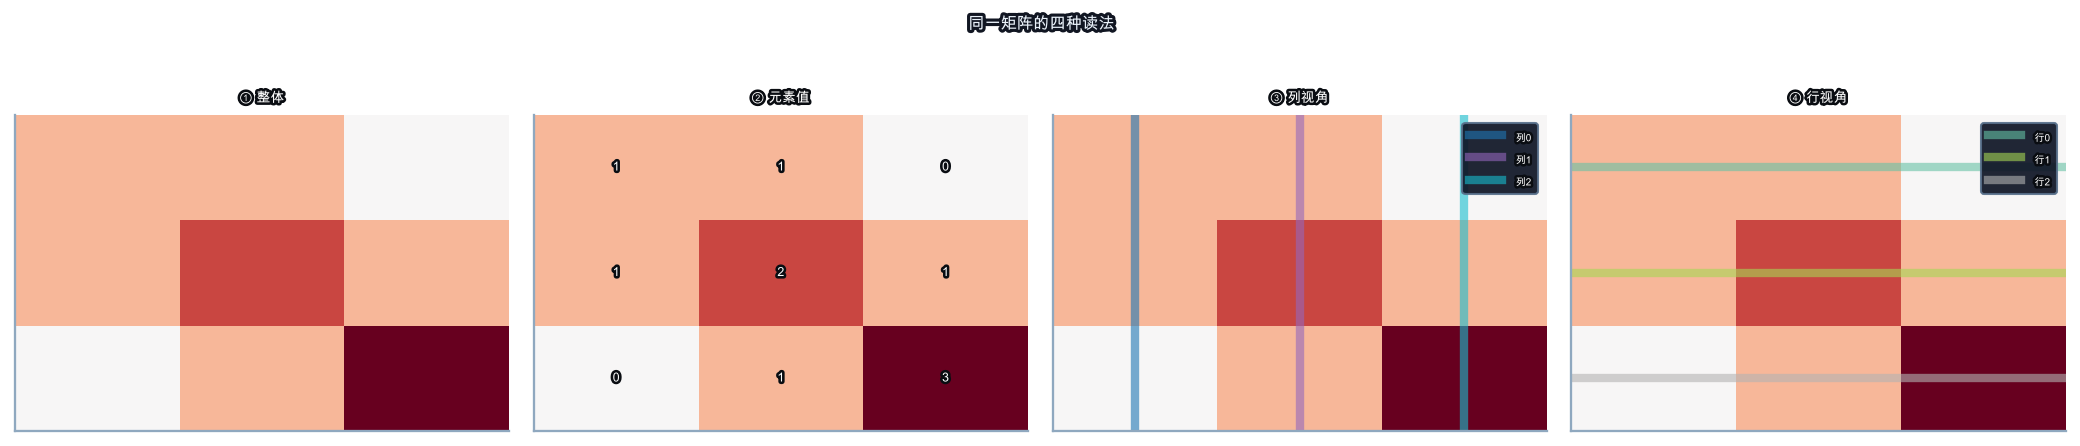

In [18]:
from aurora.laviz import style, matrix_4ways
style()
matrix_4ways([[1,1,0],[1,2,1],[0,1,3]]);

In [19]:
import numpy as np

# 参数实验：行列式随矩阵元素变化
# A = [[a, 1],[1, a]]  => det = a²-1
for a in [-2., -1., 0., 1., 2., 3.]:
    A = np.array([[a, 1.],[1., a]])
    d = np.linalg.det(A)
    inv = '可逆' if abs(d)>1e-10 else '奇异'
    print(f'a={a:+.0f}  det={d:+.2f}  → {inv}')
print('→ a=±1 时 det=0，矩阵奇异不可逆。')


a=-2  det=+3.00  → 可逆
a=-1  det=+0.00  → 奇异
a=+0  det=-1.00  → 可逆
a=+1  det=+0.00  → 奇异
a=+2  det=+3.00  → 可逆
a=+3  det=+8.00  → 可逆
→ a=±1 时 det=0，矩阵奇异不可逆。


## 参数实验：随机矩阵与奇异矩阵对比

构造 `A = np.random.rand(3, 3)` 多次，打印 `np.linalg.det(A)`，确认随机 3×3 矩阵几乎总是可逆的。再把第二行设成第一行的两倍：`A[1] = 2 * A[0]`，重新计算 det，确认它变为 0（或因浮点舍入极接近 0）。同时用 `np.linalg.cond(A)` 对比两种情况：随机矩阵条件数（condition number，κ）通常在 10–100 之间，奇异矩阵条件数爆到 1e15 以上。

## 本课收束

现在能用 `det_2x2` 和 `inv_2x2` 验证任意 2×2 矩阵是否可逆，用余子式展开处理 3×3 情形。在 Aurora 协方差白化步骤中，先算 det 来决定能否安全调用求逆。下一节的特征分解会用 det=0 来识别奇异矩阵，这是今天结论的直接延伸。

---
⬇️ **通关检验**：收束小结已读；请完成下方白板挑战后再勾选自评。


## ✏️ 白板挑战：行列式与逆矩阵手算（目标 10 分钟）

盖上屏幕，纸上作答：

**问 1**：A = [[3, 1], [2, 4]]，手算 det(A)。公式：ad − bc。

**问 2**：B = [[4, 3], [6, 3]]，手算 det(B)，再用闭式公式写出 B⁻¹。
公式：B⁻¹ = (1/det(B)) · [[d, -b], [-c, a]]

**问 3**：C = [[1, 2], [2, 4]]，det(C) = ? 能求 C⁻¹ 吗？为什么？

**问 4**：如果 det(A) = −5，它的几何含义是什么？  
（面积缩放倍数？翻转了吗？）

> 提示：如果不确定"翻转"具体指什么，回顾前面「翻转到底是什么？—— 镜子 vs. 转盘」那一节的镜像矩阵例子。

推导完成后运行下面格对答案。

In [20]:
# ✏️ 对答案格
import numpy as np

# 问1：det([[3,1],[2,4]])
A1 = np.array([[3., 1.], [2., 4.]])
try:
    d1 = det_2x2(A1)
    assert np.isclose(d1, 10.0, atol=1e-10), f"det 应为 10，得到 {d1}"
    print(f"Q1 ✅  det([[3,1],[2,4]]) = 3×4-1×2 = {d1}")
except (NotImplementedError, TypeError):
    print("⬜ Q1：请先实现 det_2x2()，再运行对答案格")

# 问2：inv([[4,3],[6,3]])
B = np.array([[4., 3.], [6., 3.]])
det_B = 4*3 - 3*6  # = 12-18 = -6
B_inv_ref = np.linalg.inv(B)
try:
    got_inv = inv_2x2(B)
    assert np.allclose(got_inv, B_inv_ref, atol=1e-10)
    print(f"Q2 ✅  det(B)={det_B}, B⁻¹ = (1/{det_B})·[[3,-3],[-6,4]] = \n{got_inv}")
except (NotImplementedError, TypeError):
    print("⬜ Q2：请先实现 inv_2x2()，再运行对答案格")
assert np.isclose(det_B, -6.0, atol=1e-10)

# 问3：奇异矩阵 det=0
C = np.array([[1., 2.], [2., 4.]])
det_C_hand = 1*4 - 2*2
assert det_C_hand == 0
print(f"\nQ3 ✅  det([[1,2],[2,4]]) = {det_C_hand} → 奇异矩阵，不可逆（两行成比例）")

# 问4：det=-5 的几何意义
print(f"\nQ4 ✅  det(A)=-5：")
print(f"       |det|=5 → 面积放大5倍")
print(f"       det<0   → 发生了翻转（左手变右手，有向面积为负）")
print("\n🎉 行列式与逆矩阵白板挑战通过！det=0 ↔ 不可逆已内化。")

⬜ Q1：请先实现 det_2x2()，再运行对答案格
⬜ Q2：请先实现 inv_2x2()，再运行对答案格

Q3 ✅  det([[1,2],[2,4]]) = 0 → 奇异矩阵，不可逆（两行成比例）

Q4 ✅  det(A)=-5：
       |det|=5 → 面积放大5倍
       det<0   → 发生了翻转（左手变右手，有向面积为负）

🎉 行列式与逆矩阵白板挑战通过！det=0 ↔ 不可逆已内化。


In [ ]:
# ✏️ 本课自评
l16_review = {
    "det_2x2_implemented":  None,  # det_2x2 实现并通过断言？True/False
    "inv_2x2_implemented":  None,  # inv_2x2 实现并通过断言？True/False
    "det_geometry_intuition": None, # 理解 det = 有向面积/体积缩放？True/False
    "singular_det_zero":    None,  # 知道 det=0 ↔ 不可逆？True/False
    "whiteboard_passed":    None,  # 白板挑战纸上推导完成？True/False
}

unfilled = [k for k, v in l16_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l16_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L16 全部通关！进入 L17：特征分解')

---

→ **下一课**　[L17 · 特征分解 A=PDP⁻¹](L17_eigen_diagonalization.ipynb)

> 下节课将学习 **特征分解 A=PDP⁻¹**：换坐标系让矩阵乘法变成标量乘法。